# Heavy-Tailed Gradient Noise Benchmark

Reproduces **Figure 3** from *"On Surprising Effectiveness of Masking Updates in Adaptive Optimizers"* (arXiv 2602.15322) https://arxiv.org/abs/2602.15322 .

This should show that Magma substantially outperforms Adam under heavy-tailed gradient noise distributions (common in LLM training), while matching performance under light-tailed (Gaussian) noise.

A simplified linear transformer trained on random linear regression tasks (meta-learning format). We compare two data distributions:
- **Light-tailed:** Normal covariates (Gaussian gradient noise)
- **Heavy-tailed:** Unit-sphere covariates scaled by Gamma (heavy-tailed gradient noise)

In [1]:
!pip install -q git+https://github.com/andrijdavid/magma-optimizer.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from magma import Magma

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 123456789
torch.manual_seed(SEED)

## Linear Transformer for In-Context Linear Regression

Following the paper's setup (Appendix B.4): a simplified linear attention transformer that learns to solve random linear regression problems presented in-context.

In [3]:
class LinearAttentionLayer(nn.Module):
    """Single-head linear attention (no softmax), following Ahn et al. (2024)."""
    def __init__(self, d_model):
        super().__init__()
        # In Ahn et al. 2024, attention is parameterized by a single matrix Q
        # representing the product of key, query matrices.
        self.P = nn.Linear(d_model, d_model, bias=False)
        self.Q = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x):
        # x: (batch, seq, d_model)
        # Context tokens are all except the last one.
        x_ctx = x[:, :-1, :] # (batch, n, d_model)

        # Residual connection scaled by 1/n
        n = x.shape[1] - 1
        
        # M zeroes out the query token when computing the attention matrix
        # Z M Z^T is just the uncentered covariance of the context tokens
        cov = torch.bmm(x_ctx.transpose(1, 2), x_ctx) / n # (batch, d_model, d_model)
        
        # Apply Q matrix to Z (i.e. x.transpose(1,2))
        # self.Q(x) computes X @ Q^T. So its transpose is Q @ X^T = Q @ Z
        QZ = self.Q(x).transpose(1, 2) # (batch, d_model, seq)
        
        # Z M Z^T Q Z
        CQZ = torch.bmm(cov, QZ) # (batch, d_model, seq)
        
        # Apply P matrix
        # self.P(CQZ.transpose(1, 2)) computes (C Q Z)^T @ P^T = (P C Q Z)^T
        out = self.P(CQZ.transpose(1, 2)) # (batch, seq, d_model)
        
       
        return x + out 


class LinearTransformer(nn.Module):
    """Simple linear transformer for in-context learning."""
    def __init__(self, d_input, n_layers=3):
        super().__init__()
        # The state vector has dimension d_model = d_input + 1
        self.d_model = d_input + 1
        self.layers = nn.ModuleList([LinearAttentionLayer(self.d_model) for _ in range(n_layers)])
        for layer in self.layers:
            nn.init.normal_(layer.P.weight, std=0.02)
            nn.init.normal_(layer.Q.weight, std=0.02)


    def forward(self, x, y):
        """
        x: (batch, seq, d_input)  — covariates
        y: (batch, seq, 1)        — targets
        """
        # Zero out last y (query) as it's the target to be predicted
        y_input = y.clone()
        y_input[:, -1, :] = 0.0
        
        # The state is simply the concatenation of covariates and targets
        h = torch.cat([x, y_input], dim=-1) # (batch, seq, d_model)
        
        for attn in self.layers:
            h = attn(h)
            
        # The output is the negative of the bottom-right entry of the final state
        # (the predicted y for the query)
        pred = -h[:, -1, -1:] 
        return pred

In [4]:
def sample_linear_regression_task(batch_size, seq_len, d_input, heavy_tailed=False):
    """Sample random linear regression tasks according to Appendix B.4.
    
    w ~ N(0, I_d). 
    Light-tailed: x ~ N(0, I_d).
    Heavy-tailed: x ~ Uniform(S^{d-1}) * sqrt(Gamma(0.1, 10)).
    """
    # Random weight vector per task
    w = torch.randn(batch_size, d_input, 1, device=device)
    
    if heavy_tailed:
        # x sampled from unit sphere
        x = torch.randn(batch_size, seq_len, d_input, device=device)
        x = x / (x.norm(dim=-1, keepdim=True) + 1e-8)
        # Scaled by sqrt of Gamma distribution (shape=0.1, scale=10)
        gamma = torch.distributions.Gamma(0.1, 0.1).sample((batch_size, seq_len, 1)).to(device)
        x = x * gamma.sqrt()
    else:
        x = torch.randn(batch_size, seq_len, d_input, device=device)
    
    # Target y = x @ w (noiseless context as per paper)
    y = (x @ w)
    return x, y

In [5]:
D_INPUT = 5
SEQ_LEN = 21  # n=20 context length + 1 query
BATCH_SIZE = 64
STEPS = 10000
LR = 1e-4


def train_run(heavy_tailed, use_magma, seed=42):
    """Train linear transformer and return loss curve."""
    torch.manual_seed(seed)
    model = LinearTransformer(d_input=D_INPUT, n_layers=3).to(device)
    
    base_opt = torch.optim.Adam(model.parameters(), lr=LR)
    if use_magma:
        # Apply Magma to all parameters since this simplified model only has attention layers
        optimizer = Magma(base_opt, mask_prob=0.5, tau=2.0)
    else:
        optimizer = base_opt
    
    losses = []
    for step in range(1, STEPS + 1):
        x, y = sample_linear_regression_task(BATCH_SIZE, SEQ_LEN, D_INPUT, heavy_tailed=heavy_tailed)
        optimizer.zero_grad()
        pred = model(x, y)
        target = y[:, -1, :]
        
        loss = nn.MSELoss()(pred, target)
        if not torch.isfinite(loss):
            print(f"Non-finite loss at step {step}; stopping this run.")
            break
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        losses.append(loss.item())
        
        if step % 2000 == 0:
            tag = f"{'Heavy' if heavy_tailed else 'Light'}-{'Magma' if use_magma else 'Adam'}"
            print(f"  [{tag}] Step {step}/{STEPS} | Loss: {loss.item():.6f}")
    
    return losses

In [6]:
results = {}

for heavy_tailed in [False, True]:
    noise_type = "Heavy-tailed" if heavy_tailed else "Light-tailed"
    print(f"\n{'='*50}")
    print(f"{noise_type} covariates")
    print(f"{'='*50}")
    for use_magma in [False, True]:
        label = f"{'Adam+Magma' if use_magma else 'Adam'}"
        print(f"\nTraining {label}...")
        losses = train_run(heavy_tailed, use_magma)
        results[(noise_type, label)] = losses


Light-tailed covariates

Training Adam...
  [Light-Adam] Step 2000/10000 | Loss: 19.778086
  [Light-Adam] Step 4000/10000 | Loss: 2.588845
  [Light-Adam] Step 6000/10000 | Loss: 1.742554
  [Light-Adam] Step 8000/10000 | Loss: 2.760172
  [Light-Adam] Step 10000/10000 | Loss: 1.681396

Training Adam+Magma...
  [Light-Magma] Step 2000/10000 | Loss: 5.720949
  [Light-Magma] Step 4000/10000 | Loss: 3.290864
  [Light-Magma] Step 6000/10000 | Loss: 4.785934
  [Light-Magma] Step 8000/10000 | Loss: 4.591893
  [Light-Magma] Step 10000/10000 | Loss: 3.259257

Heavy-tailed covariates

Training Adam...
  [Heavy-Adam] Step 2000/10000 | Loss: 0.714196
  [Heavy-Adam] Step 4000/10000 | Loss: 0.217829
  [Heavy-Adam] Step 6000/10000 | Loss: 0.307626
  [Heavy-Adam] Step 8000/10000 | Loss: 0.583939
  [Heavy-Adam] Step 10000/10000 | Loss: 0.854056

Training Adam+Magma...
  [Heavy-Magma] Step 2000/10000 | Loss: 0.702081
  [Heavy-Magma] Step 4000/10000 | Loss: 0.930131
  [Heavy-Magma] Step 6000/10000 | Loss:

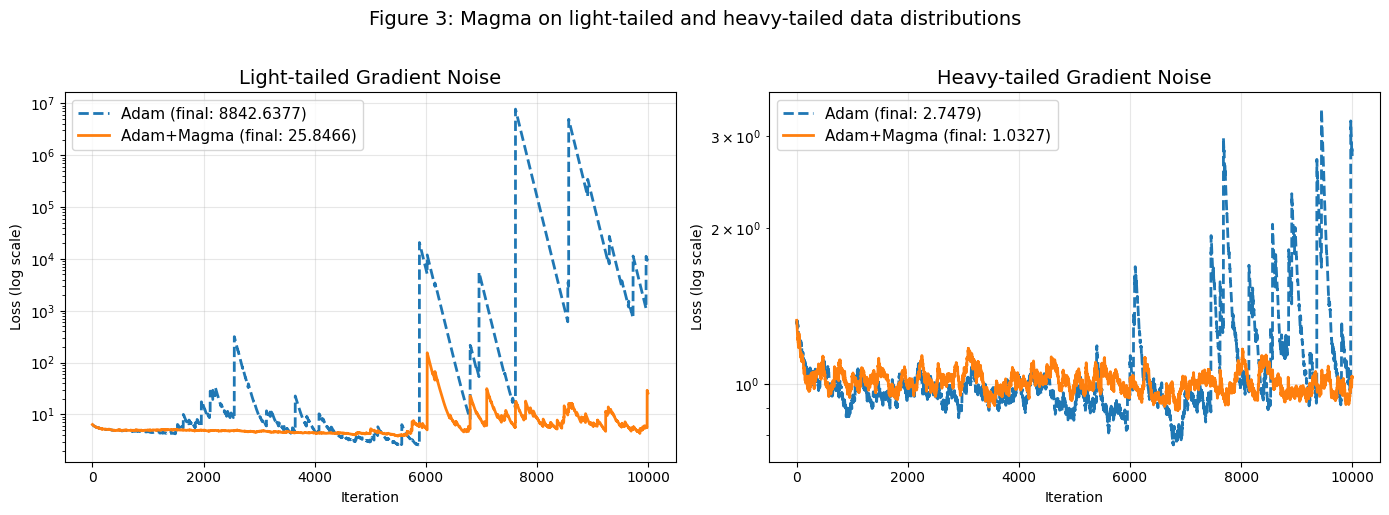

In [7]:
def smooth(values, weight=0.99):
    s = []
    if not values: return []
    last = values[0]
    for v in values:
        last = weight * last + (1 - weight) * v
        s.append(last)
    return s


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {"Adam": "#1f77b4", "Adam+Magma": "#ff7f0e"}
styles = {"Adam": "--", "Adam+Magma": "-"}

for i, noise_type in enumerate(["Light-tailed", "Heavy-tailed"]):
    ax = axes[i]
    for label in ["Adam", "Adam+Magma"]:
        raw_losses = results.get((noise_type, label), [])
        if not raw_losses: continue
        curve = smooth(raw_losses)
        final = curve[-1]
        ax.semilogy(curve, label=f"{label} (final: {final:.4f})",
                    color=colors[label], linestyle=styles[label], linewidth=2)
    ax.set_title(f"{noise_type} Gradient Noise", fontsize=14)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Loss (log scale)")
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

fig.suptitle("Figure 3: Magma on light-tailed and heavy-tailed data distributions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

- **Light-tailed:** Adam and Adam+Magma should perform comparably, mirroring the left plot in Figure 3.
- **Heavy-tailed:** Adam+Magma should substantially outperform Adam, mirroring the right plot in Figure 3. The stochastic masking + alignment gating in Magma effectively handles heavy-tailed gradient noise by suppressing outlier-driven updates that would otherwise destabilize Adam's second-moment estimates.